# 22 — Resource comparability across time

**Goal.** Decide which resources can support a *like-for-like* partial-order analysis across the three periods (Classical, Late Classical, Roman) for the four canonical groups: `Citizens`, `Women`, `Slaves`, `Foreigners`.

Two questions drive this notebook:

1. **Are the resources comparable in time?** A resource bucket is only useful as a partial-order axis if it is *attested in every period* with enough rules to be meaningful.
2. **Do the resources mean the same thing in every period?** A bucket like `Right to bodily autonomy` may refer to citizen-male physical inviolability in the Classical corpus but to slave sexual integrity in the Roman corpus. The bucket label hides the drift — we audit the underlying `resource` strings to spot this.

From the two audits we derive a curated `COMPARABLE_RIGHTS` subset that is both temporally and semantically stable, then re-run the Hasse partial order on it.

In [1]:
from pathlib import Path
from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np
import networkx as nx
import pandas as pd
from matplotlib.patches import Patch

pd.set_option('display.max_colwidth', 110)
pd.set_option('display.max_rows', 100)

DATA_PATH = Path('../data/rules_dataset_april_2026.tsv')

PERIOD_MAP = {
    'Classical (500–360 BCE)':                      'Classical (500–360 BCE)',
    'Late Classical (354–165 BCE)':                 'Late Classical (354–165 BCE)',
    'Hellenistic & Early Roman (165 BCE – 105 CE)': 'Roman (165 BCE – 205 CE)',
    'High Roman Empire (135–205 CE)':               'Roman (165 BCE – 205 CE)',
}
PERIOD_ORDER = [
    'Classical (500–360 BCE)',
    'Late Classical (354–165 BCE)',
    'Roman (165 BCE – 205 CE)',
]

GREEK_POLITIES = {
    'Classical Athens', 'Hellenistic Athens', 'Archaic Athens',
    'Archaic Athens (Solonic)', 'Archaic Athens (Draconian)',
    'Archaic Athens (Peisistratid)', 'Archaic Athens (Pre-Solonic)',
    'Classical Athens (Solonic)', 'Classical Athens (Cleisthenic)',
    'Classical Athens (Eleusis)', 'Classical Athens (The Four Hundred)',
    'Classical Athens (The Five Thousand)', 'Classical Athens (the Five Thousand)',
    'Classical Sparta', 'Sparta', 'Archaic Sparta',
    'Classical Greece', 'Ancient Greece', 'Hellenistic Greece', 'Hellenistic Greek states',
    'Classical Thebes', 'Syracuse', 'Sicyon', 'Corinth', 'Aegina',
    'Mantineia', 'Mytilene', 'Oreus', 'Acragas', 'Delphi', 'Crete',
    'Chalcidice', 'Salamis (Cyprus)', 'Ionia and Pontus', 'Tarsus',
    'League of Corinth', 'Achaean League', 'Delphic Amphictyonic League',
    'Hellenistic Macedon', 'Macedonian Empire', 'Seleucid Empire',
    'Hierapolis (Syria)', 'Hellenistic Hierapolis',
    'Mythological / legendary setting',
}

GROUP_DROP   = {'Other'}
GROUP_RENAME = {'The poor': 'The poor / multitude', 'The multitude': 'The poor / multitude'}

RESOURCE_BUCKET = {
    'Right to own land':                          'Right to own property',
    'Right to retain own earnings':               'Right to retain property',
    'Right to dispose of property':               'Right to dispose / inherit property',
    'Right to inherit property':                  'Right to dispose / inherit property',
    'Right to inherit divine covenant':           'Right to dispose / inherit property',
    'Right to address the assembly':              'Right to public speech',
    'Right to speak first in assembly':           'Right to public speech',
    'Right to free speech':                       'Right to public speech',
    'Right to remuneration for office':           'Eligibility for public office',
    'Right to reside in the city':                'Right to reside / freedom of movement',
    'Right to freedom of movement':               'Right to reside / freedom of movement',
    'Right to a dowry':                           'Right to marriage / dowry',
    'Right to marry':                             'Right to marriage / dowry',
    'Right to professional judgement':            'Right to a legal trial',
    'Right to valid professional opinion':        'Right to a legal trial',
    'Right to military protection':               'Right to bear arms / military protection',
    'Right to bear arms':                         'Right to bear arms / military protection',
    'Protection from arbitrary banishment':       'Protection from banishment / prosecution',
    'Protection from legal prosecution':          'Protection from banishment / prosecution',
    'Protection from capital punishment':         'Protection from capital / corporal punishment',
    'Protection from corporal punishment':        'Protection from capital / corporal punishment',
    'Exemption from compulsory public financing': 'Exemption from taxes / public financing',
    'Exemption from public service financing':    'Exemption from taxes / public financing',
    'Exemption from taxes':                       'Exemption from taxes / public financing',
    'Exemption from manual labor':                'Exemption from compulsory service',
    'Exemption from military service':            'Exemption from compulsory service',
}

OPPOSITE_GROUP = {
    'Women':                'Men',  'Wives':                'Men',
    'Men':                  None,   'Minors':               'Men',
    'Elders':               'Men',  'Orphans':              'Heirs',
    'Heirs':                None,
    'Slaves':               'Citizens', 'Foreigners':       'Citizens',
    'Exiles':               'Citizens', 'Citizens':         None,
    'Macedonians':          'Greeks',   'Scythians':         'Greeks',
    'Syrians':              'Greeks',   'Greeks':            None,
    'Spartans':             None,
    'The poor / multitude': 'The wealthy', 'The wealthy':    None,
    'Sick':                 'Men',  'Physicians':           None,
    'Kings':                None,   'Nobles':               None,
    'Magistrates':          None,   'Artisans':             None,
    'Poets':                None,   'Priests':              None,
    'Soldiers':             None,   'Sailors':              None,
    'Philosophers':         None,   'The educated':         None,
    'Christians':           None,   'Jews':                 None,
    'Romans':               None,
}

CANONICAL_GROUPS = ['Citizens', 'Women', 'Slaves', 'Foreigners']
GROUP_TO_TARGETS = {
    'Citizens': ['Citizens'], 'Foreigners': ['Foreigners'], 'Slaves': ['Slaves'],
    'Exiles': ['Citizens'], 'Men': ['Citizens'], 'Women': ['Women'], 'Wives': ['Women'],
    'Nobles': ['Citizens'], 'Magistrates': ['Citizens'], 'Kings': ['Citizens'],
    'Heirs': ['Citizens'], 'Spartans': ['Citizens'], 'Priests': ['Citizens'],
    'Soldiers': ['Citizens'], 'Sailors': ['Citizens'], 'Artisans': ['Citizens'],
    'Physicians': ['Citizens'], 'Philosophers': ['Citizens'], 'Poets': ['Citizens'],
    'The educated': ['Citizens'], 'The wealthy': ['Citizens'],
    'The poor / multitude': ['Citizens'], 'Minors': ['Citizens'], 'Orphans': ['Citizens'],
    'Elders': ['Citizens'], 'Sick': ['Citizens'], 'Greeks': ['Citizens'],
    'Macedonians': ['Foreigners'], 'Scythians': ['Foreigners'], 'Syrians': ['Foreigners'],
    'Christians': ['Citizens', 'Foreigners', 'Women'],
    'Jews':       ['Citizens', 'Foreigners', 'Women'],
    'Romans': [],
}

MIN_RULES_PER_CELL = 1
MIN_RIGHTS         = 1
OVERLAP_MIN        = 0.5

# Coverage thresholds
MIN_PER_PERIOD     = 1     # min number of rules in *each* period to call a resource time-comparable
MIN_GROUPS         = 1     # min number of canonical groups attested across periods

COLOR_MORE  = '#1f4e79'
COLOR_FLIP  = '#c97c2e'
COLOR_BOTH  = '#5a3a8a'
COLOR_EMPTY = '#f2f2f2'

In [2]:
df_raw = pd.read_csv(DATA_PATH, sep='\t')

def atoms(s):
    if pd.isna(s):
        return []
    return [x.strip() for x in str(s).split(';') if x.strip()]

base = (df_raw
          .dropna(subset=['period', 'group_meta', 'resource_meta', 'rule_polity', 'directionality'])
          .assign(period=lambda d: d['period'].map(PERIOD_MAP))
          .dropna(subset=['period']))
base = base[base['rule_polity'].isin(GREEK_POLITIES)]
base = base.assign(resource_bucket=base['resource_meta'].map(lambda r: RESOURCE_BUCKET.get(r, r)))
base = base.assign(group_cat=base['group_meta'].apply(atoms)).explode('group_cat')
base = base[~base['group_cat'].isin(GROUP_DROP)]
base = base.assign(group_cat=base['group_cat'].replace(GROUP_RENAME))

more_rows = base[base['directionality'] == 'MORE'][['period', 'group_cat', 'resource', 'resource_bucket', 'rule']]
less_rows = base[base['directionality'] == 'LESS'][['period', 'group_cat', 'resource', 'resource_bucket', 'rule']]

flipped = less_rows.assign(group_cat=less_rows['group_cat'].map(OPPOSITE_GROUP)).dropna(subset=['group_cat'])

def to_targets(frame):
    out = frame.assign(group=frame['group_cat'].map(lambda g: GROUP_TO_TARGETS.get(g, [])))
    out = out.explode('group').dropna(subset=['group'])
    return out[['period', 'group', 'resource', 'resource_bucket', 'rule']]

more_t    = to_targets(more_rows)
flipped_t = to_targets(flipped)

positive = pd.concat([more_t.assign(origin='MORE'),
                      flipped_t.assign(origin='flipped LESS')],
                     ignore_index=True)

positive.shape, positive['origin'].value_counts().to_dict()

((652, 6), {'MORE': 491, 'flipped LESS': 161})

## Question 1 — Are the resources comparable in time?

For each resource bucket, count the number of routed rules (MORE + flipped LESS) per period. A resource is *time-comparable* if it has at least `MIN_PER_PERIOD` rules in **every** period and is attested across at least `MIN_GROUPS` canonical groups in total.

In [3]:
rb_period = (positive
             .groupby(['resource_bucket', 'period'])
             .size()
             .unstack('period', fill_value=0)
             .reindex(columns=PERIOD_ORDER, fill_value=0))
rb_group = (positive
             .groupby('resource_bucket')['group']
             .nunique()
             .rename('n_groups'))
rb_summary = rb_period.join(rb_group)
rb_summary['min_period'] = rb_summary[PERIOD_ORDER].min(axis=1)
rb_summary['total']      = rb_summary[PERIOD_ORDER].sum(axis=1)
rb_summary['comparable'] = ((rb_summary['min_period'] >= MIN_PER_PERIOD) &
                            (rb_summary['n_groups']  >= MIN_GROUPS)).map({True: '✓', False: ''})
rb_summary = rb_summary.sort_values(['comparable', 'total'], ascending=[False, False])
rb_summary

,Classical (500–360 BCE),Late Classical (354–165 BCE),Roman (165 BCE – 205 CE),n_groups,min_period,total,comparable
resource_bucket,,,,,,,
Eligibility for public office,29,81,18,2,18,128,✓
Right to a legal trial,29,24,5,4,5,58,✓
Political power,14,27,12,3,12,53,✓
Protection from capital / corporal punishment,25,18,5,3,5,48,✓
Right to retain property,17,10,9,4,9,36,✓
Right to citizenship,19,10,4,3,4,33,✓
Right to dispose / inherit property,22,6,3,3,3,31,✓
Right to vote in the Ekklesia,3,19,6,2,3,28,✓
Access to public honors,4,12,7,2,4,23,✓


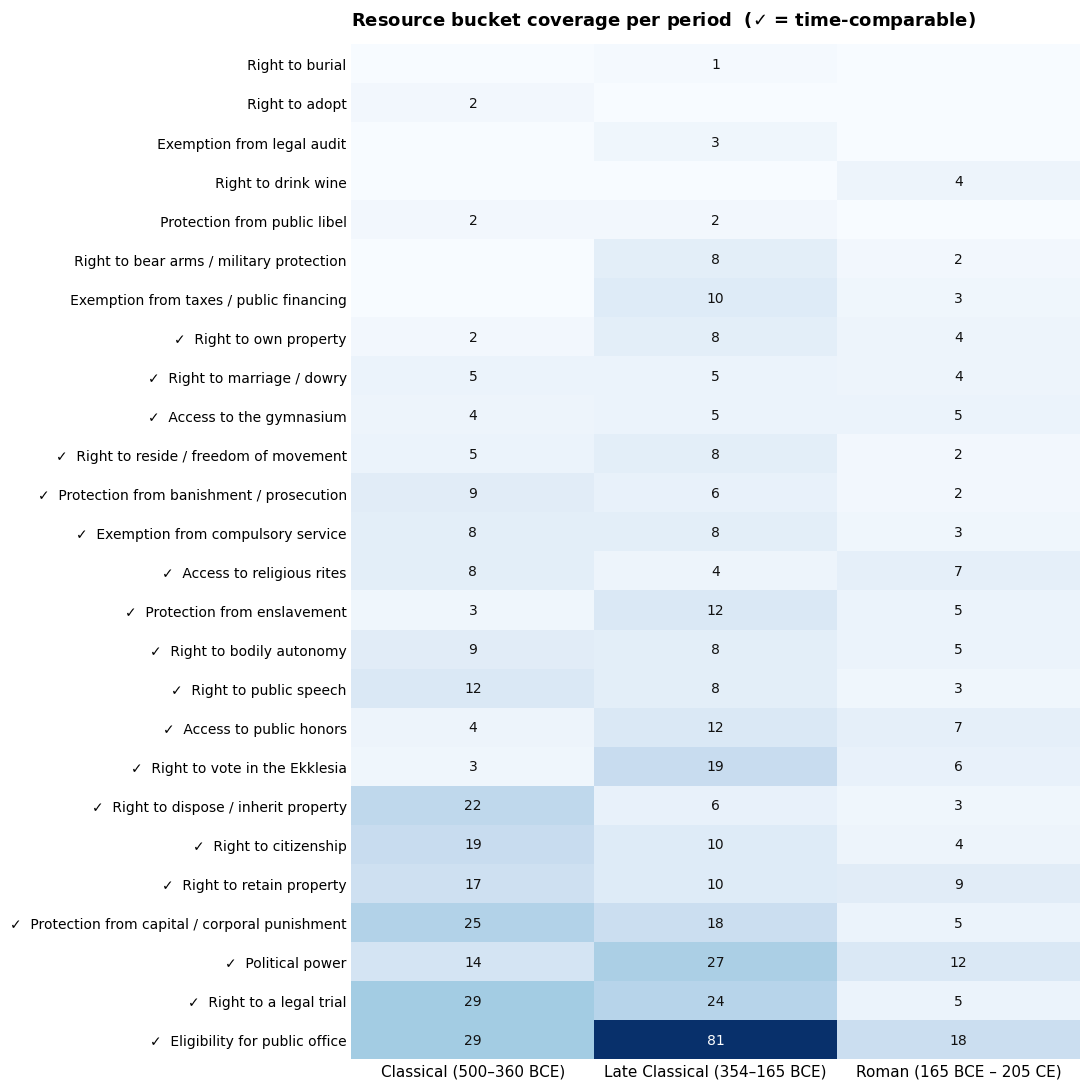

In [4]:
plt.rcParams.update({'font.family': 'DejaVu Sans'})
ordered = rb_summary.sort_values('total', ascending=True)
data = ordered[PERIOD_ORDER].values
fig, ax = plt.subplots(figsize=(11, 11))
im = ax.imshow(data, aspect='auto', cmap='Blues')
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        v = data[i, j]
        ax.text(j, i, str(v) if v else '',
                ha='center', va='center', fontsize=10,
                color='white' if v >= data.max() * 0.5 else '#111')
ax.set_xticks(range(len(PERIOD_ORDER)))
ax.set_xticklabels(PERIOD_ORDER, fontsize=11)
ax.set_yticks(range(len(ordered)))
ax.set_yticklabels([f"{('✓  ' if c == '✓' else '   ')}{idx}"
                    for idx, c in zip(ordered.index, ordered['comparable'])],
                   fontsize=10)
ax.tick_params(axis='both', length=0)
for s in ('top', 'right', 'bottom', 'left'): ax.spines[s].set_visible(False)
ax.set_title('Resource bucket coverage per period  ($\\checkmark$ = time-comparable)',
             fontsize=13, loc='left', pad=14, weight='semibold')
fig.tight_layout()
plt.show()

## Question 2 — Are the resources the same?

Even if a bucket is attested in all three periods, the underlying meaning can drift. The TSV has a finer-grained column `resource` (raw label) under each `resource_bucket`. The next view shows, for every time-comparable bucket, the granular `resource` strings and their counts per period.

**Red flag pattern.** If the granular strings dominant in one period are entirely absent in another, the bucket label is hiding semantic drift — e.g. *Protection from capital/corporal punishment* may collapse two genuinely different rights (citizen capital-punishment exemption in Classical vs slave whipping protection in Roman).

In [5]:
comparable_buckets = rb_summary[rb_summary['comparable'] == '✓'].index.tolist()
print(f'{len(comparable_buckets)} time-comparable buckets:')
for b in comparable_buckets:
    print(' -', b)

19 time-comparable buckets:
 - Eligibility for public office
 - Right to a legal trial
 - Political power
 - Protection from capital / corporal punishment
 - Right to retain property
 - Right to citizenship
 - Right to dispose / inherit property
 - Right to vote in the Ekklesia
 - Access to public honors
 - Right to public speech
 - Right to bodily autonomy
 - Protection from enslavement
 - Access to religious rites
 - Exemption from compulsory service
 - Protection from banishment / prosecution
 - Right to reside / freedom of movement
 - Access to the gymnasium
 - Right to marriage / dowry
 - Right to own property


In [6]:
granular = (positive[positive['resource_bucket'].isin(comparable_buckets)]
            .groupby(['resource_bucket', 'resource', 'period'])
            .size()
            .unstack('period', fill_value=0)
            .reindex(columns=PERIOD_ORDER, fill_value=0)
            .reset_index())

def drift_score(row):
    vals = row[PERIOD_ORDER].values
    return int(sum(vals > 0))   # 1 / 2 / 3 = how many periods the granular resource appears in

granular['periods_present'] = granular.apply(drift_score, axis=1)
granular = granular.sort_values(['resource_bucket', 'periods_present'], ascending=[True, False])
granular

period,resource_bucket,resource,Classical (500–360 BCE),Late Classical (354–165 BCE),Roman (165 BCE – 205 CE),periods_present
0,Access to public honors,Access to common meals,0,1,0,1
1,Access to public honors,Access to educational mentorship,2,0,0,1
2,Access to public honors,Access to political honors,0,1,0,1
3,Access to public honors,Access to public festival funds,0,1,0,1
4,Access to public honors,Access to public subsidies,1,0,0,1
...,...,...,...,...,...,...
408,Right to vote in the Ekklesia,Right to equal suffrage,0,0,2,1
409,Right to vote in the Ekklesia,Right to participate in the assembly,0,1,0,1
410,Right to vote in the Ekklesia,Right to the franchise,0,4,0,1
411,Right to vote in the Ekklesia,Right to vote in ostracism,0,0,1,1


In [7]:
balance = rb_summary.copy()
balance['min_max_balance'] = (balance[PERIOD_ORDER].min(axis=1) /
                              balance[PERIOD_ORDER].max(axis=1).replace(0, 1))
balance = balance[balance['comparable'] == '✓']
balance = balance.sort_values('min_max_balance', ascending=False)
balance[PERIOD_ORDER + ['total', 'n_groups', 'min_max_balance']].style.format({
    'min_max_balance': '{:.0%}',
}).background_gradient(subset=['min_max_balance'], cmap='Greens')

,Classical (500–360 BCE),Late Classical (354–165 BCE),Roman (165 BCE – 205 CE),total,n_groups,min_max_balance
resource_bucket,,,,,,
Right to marriage / dowry,5,5,4,14,3,80%
Access to the gymnasium,4,5,5,14,4,80%
Right to bodily autonomy,9,8,5,22,2,56%
Right to retain property,17,10,9,36,4,53%
Access to religious rites,8,4,7,19,2,50%
Political power,14,27,12,53,3,44%
Exemption from compulsory service,8,8,3,19,1,38%
Access to public honors,4,12,7,23,2,33%
Right to public speech,12,8,3,23,4,25%


In [8]:
def sample_rules(bucket, n=1):
    rows = []
    for p in PERIOD_ORDER:
        sub = positive[(positive['resource_bucket'] == bucket) & (positive['period'] == p)]
        for _, r in sub.head(n).iterrows():
            rows.append({'period': p.split(' (')[0], 'group': r['group'],
                         'resource': r['resource'], 'rule': r['rule'][:140]})
    return pd.DataFrame(rows)

for b in comparable_buckets:
    print(f'\n=== {b} ===')
    print(sample_rules(b, n=1).to_string(index=False))


=== Eligibility for public office ===
        period    group                       resource                               rule
     Classical Citizens Eligibility for the archonship   Universal access to magistracies
Late Classical Citizens Eligibility for the archonship       Elite access to magistracies
         Roman Citizens    Eligibility for the cavalry Citizen cavalry service obligation

=== Right to a legal trial ===
        period    group                                   resource                                 rule
     Classical Citizens                Right to legal adjudication Liturgical adjudication requirements
Late Classical Citizens         Right to legal standing for others       General right to claim redress
         Roman Citizens Right to professional legal representation       Citizen right to legal counsel

=== Political power ===
        period    group                           resource                                 rule
     Classical Citizens         

## Curated subset — `COMPARABLE_RIGHTS`

A bucket passes the *time-comparable* test if it has rules in every period **and** spans ≥ 2 canonical groups (column `comparable` above). 17 buckets pass.

But Question 2 — *do they mean the same thing?* — is judgment work, not an automatic filter. The granular `resource` strings are noisy LLM labels; the sample-rule view above is the actual evidence. Reviewing those, we keep buckets where the concept is clearly invariant across periods (e.g. *Right to vote in the Ekklesia*) and drop buckets where the bucket label collapses different sub-concepts under one heading (e.g. *Access to religious rites*, which mixes pagan-festival access in Classical with Christian/Jewish initiation in Roman; *Right to bodily autonomy*, which covers citizen-male physical inviolability in Classical but slave sexual integrity later).

The curated list below is editable — replace it with whatever survives your audit.

In [9]:
# Hand-curated subset. Edit this list after auditing the granular drift and sample texts above.
# Each entry is a bucket whose concept stays roughly invariant across the three periods.
COMPARABLE_RIGHTS = [
    'Eligibility for public office',          # holding magistracies — stable across periods
    'Political power',                        # broad governing power — stable
    'Right to a legal trial',                 # judicial standing — stable
    'Right to vote in the Ekklesia',          # assembly voting — clearly stable
    'Right to dispose / inherit property',    # testamentary / inheritance — stable
    'Right to retain property',               # personal estate retention — stable
    'Right to public speech',                 # speaking in assembly — stable
    'Right to marriage / dowry',              # marital / dowry rights — stable
    'Protection from capital / corporal punishment',  # state violence on body — stable
]

DROPPED_WHY = {
    'Right to citizenship':                 'meaning of "citizen" shifts radically (deme registration → universal Roman grant)',
    'Access to religious rites':            'mixes pagan vs Christian/Jewish initiation',
    'Right to bodily autonomy':             'citizen physical inviolability vs slave/woman sexual integrity',
    'Access to the gymnasium':              'civic athletics → social-status marker; drifts',
    'Access to public honors':              'public subsidies → state maintenance → Prytaneum — heterogeneous',
    'Protection from banishment / prosecution':  'banishment vs ordinary legal harassment collapsed',
    'Protection from enslavement':          'small sample, semantically narrow',
    'Right to own property':                'subset of retain/dispose buckets, low coverage',
}

print(f'KEEP ({len(COMPARABLE_RIGHTS)}):')
for r in COMPARABLE_RIGHTS:
    print(' -', r)

print('\nDROP (with rationale):')
for r, why in DROPPED_WHY.items():
    print(f' - {r}  —  {why}')

KEEP (9):
 - Eligibility for public office
 - Political power
 - Right to a legal trial
 - Right to vote in the Ekklesia
 - Right to dispose / inherit property
 - Right to retain property
 - Right to public speech
 - Right to marriage / dowry
 - Protection from capital / corporal punishment

DROP (with rationale):
 - Right to citizenship  —  meaning of "citizen" shifts radically (deme registration → universal Roman grant)
 - Access to religious rites  —  mixes pagan vs Christian/Jewish initiation
 - Right to bodily autonomy  —  citizen physical inviolability vs slave/woman sexual integrity
 - Access to the gymnasium  —  civic athletics → social-status marker; drifts
 - Access to public honors  —  public subsidies → state maintenance → Prytaneum — heterogeneous
 - Protection from banishment / prosecution  —  banishment vs ordinary legal harassment collapsed
 - Protection from enslavement  —  small sample, semantically narrow
 - Right to own property  —  subset of retain/dispose buckets,

## Partial order on the curated subset

In [10]:
positive_c = positive[positive['resource_bucket'].isin(COMPARABLE_RIGHTS)]
groups     = [g for g in CANONICAL_GROUPS if g in set(positive_c['group'])]
resources  = sorted(set(positive_c['resource_bucket']))

cell_support = (positive_c
                  .groupby(['period', 'group', 'resource_bucket'])
                  .size()
                  .rename('n_rules')
                  .reset_index())
rights_long = pd.DataFrame(
    [(p, g, r) for p in PERIOD_ORDER for g in groups for r in resources],
    columns=['period', 'group', 'resource_bucket'],
).merge(cell_support, on=['period', 'group', 'resource_bucket'], how='left')
rights_long['n_rules']   = rights_long['n_rules'].fillna(0).astype(int)
rights_long['has_right'] = (rights_long['n_rules'] >= MIN_RULES_PER_CELL).astype(int)

def right_sets(period):
    sub = rights_long[(rights_long['period'] == period) & (rights_long['has_right'] == 1)]
    sets = {g: frozenset(grp['resource_bucket']) for g, grp in sub.groupby('group')}
    return {g: s for g, s in sets.items() if len(s) >= MIN_RIGHTS}

def approx_graph(sets, overlap_min=OVERLAP_MIN):
    classes = {}
    for g, s in sets.items():
        classes.setdefault(s, []).append(g)
    nodes = list(classes.keys())
    G = nx.DiGraph()
    for s in nodes:
        G.add_node(s, size=len(s))
    for a, b in combinations(nodes, 2):
        big, small = (b, a) if len(b) > len(a) else (a, b)
        if len(big) == len(small):
            continue
        if len(small & big) / len(small) >= overlap_min:
            G.add_edge(small, big)
    return nx.transitive_reduction(G), classes

def topological_positions(G):
    depth = {n: 0 for n in G.nodes}
    for n in reversed(list(nx.topological_sort(G))):
        for succ in G.successors(n):
            if depth[n] < depth[succ] + 1:
                depth[n] = depth[succ] + 1
    max_d = max(depth.values()) if depth else 0
    levels = {}
    for n in G.nodes:
        levels.setdefault(max_d - depth[n], []).append(n)
    pos = {}
    for y, nodes in levels.items():
        nodes = sorted(nodes, key=lambda s: sorted(s))
        for i, n in enumerate(nodes):
            pos[n] = ((i + 1) / (len(nodes) + 1), y)
    return pos

{p: len(right_sets(p)) for p in PERIOD_ORDER}

{'Classical (500–360 BCE)': 4,
 'Late Classical (354–165 BCE)': 4,
 'Roman (165 BCE – 205 CE)': 4}

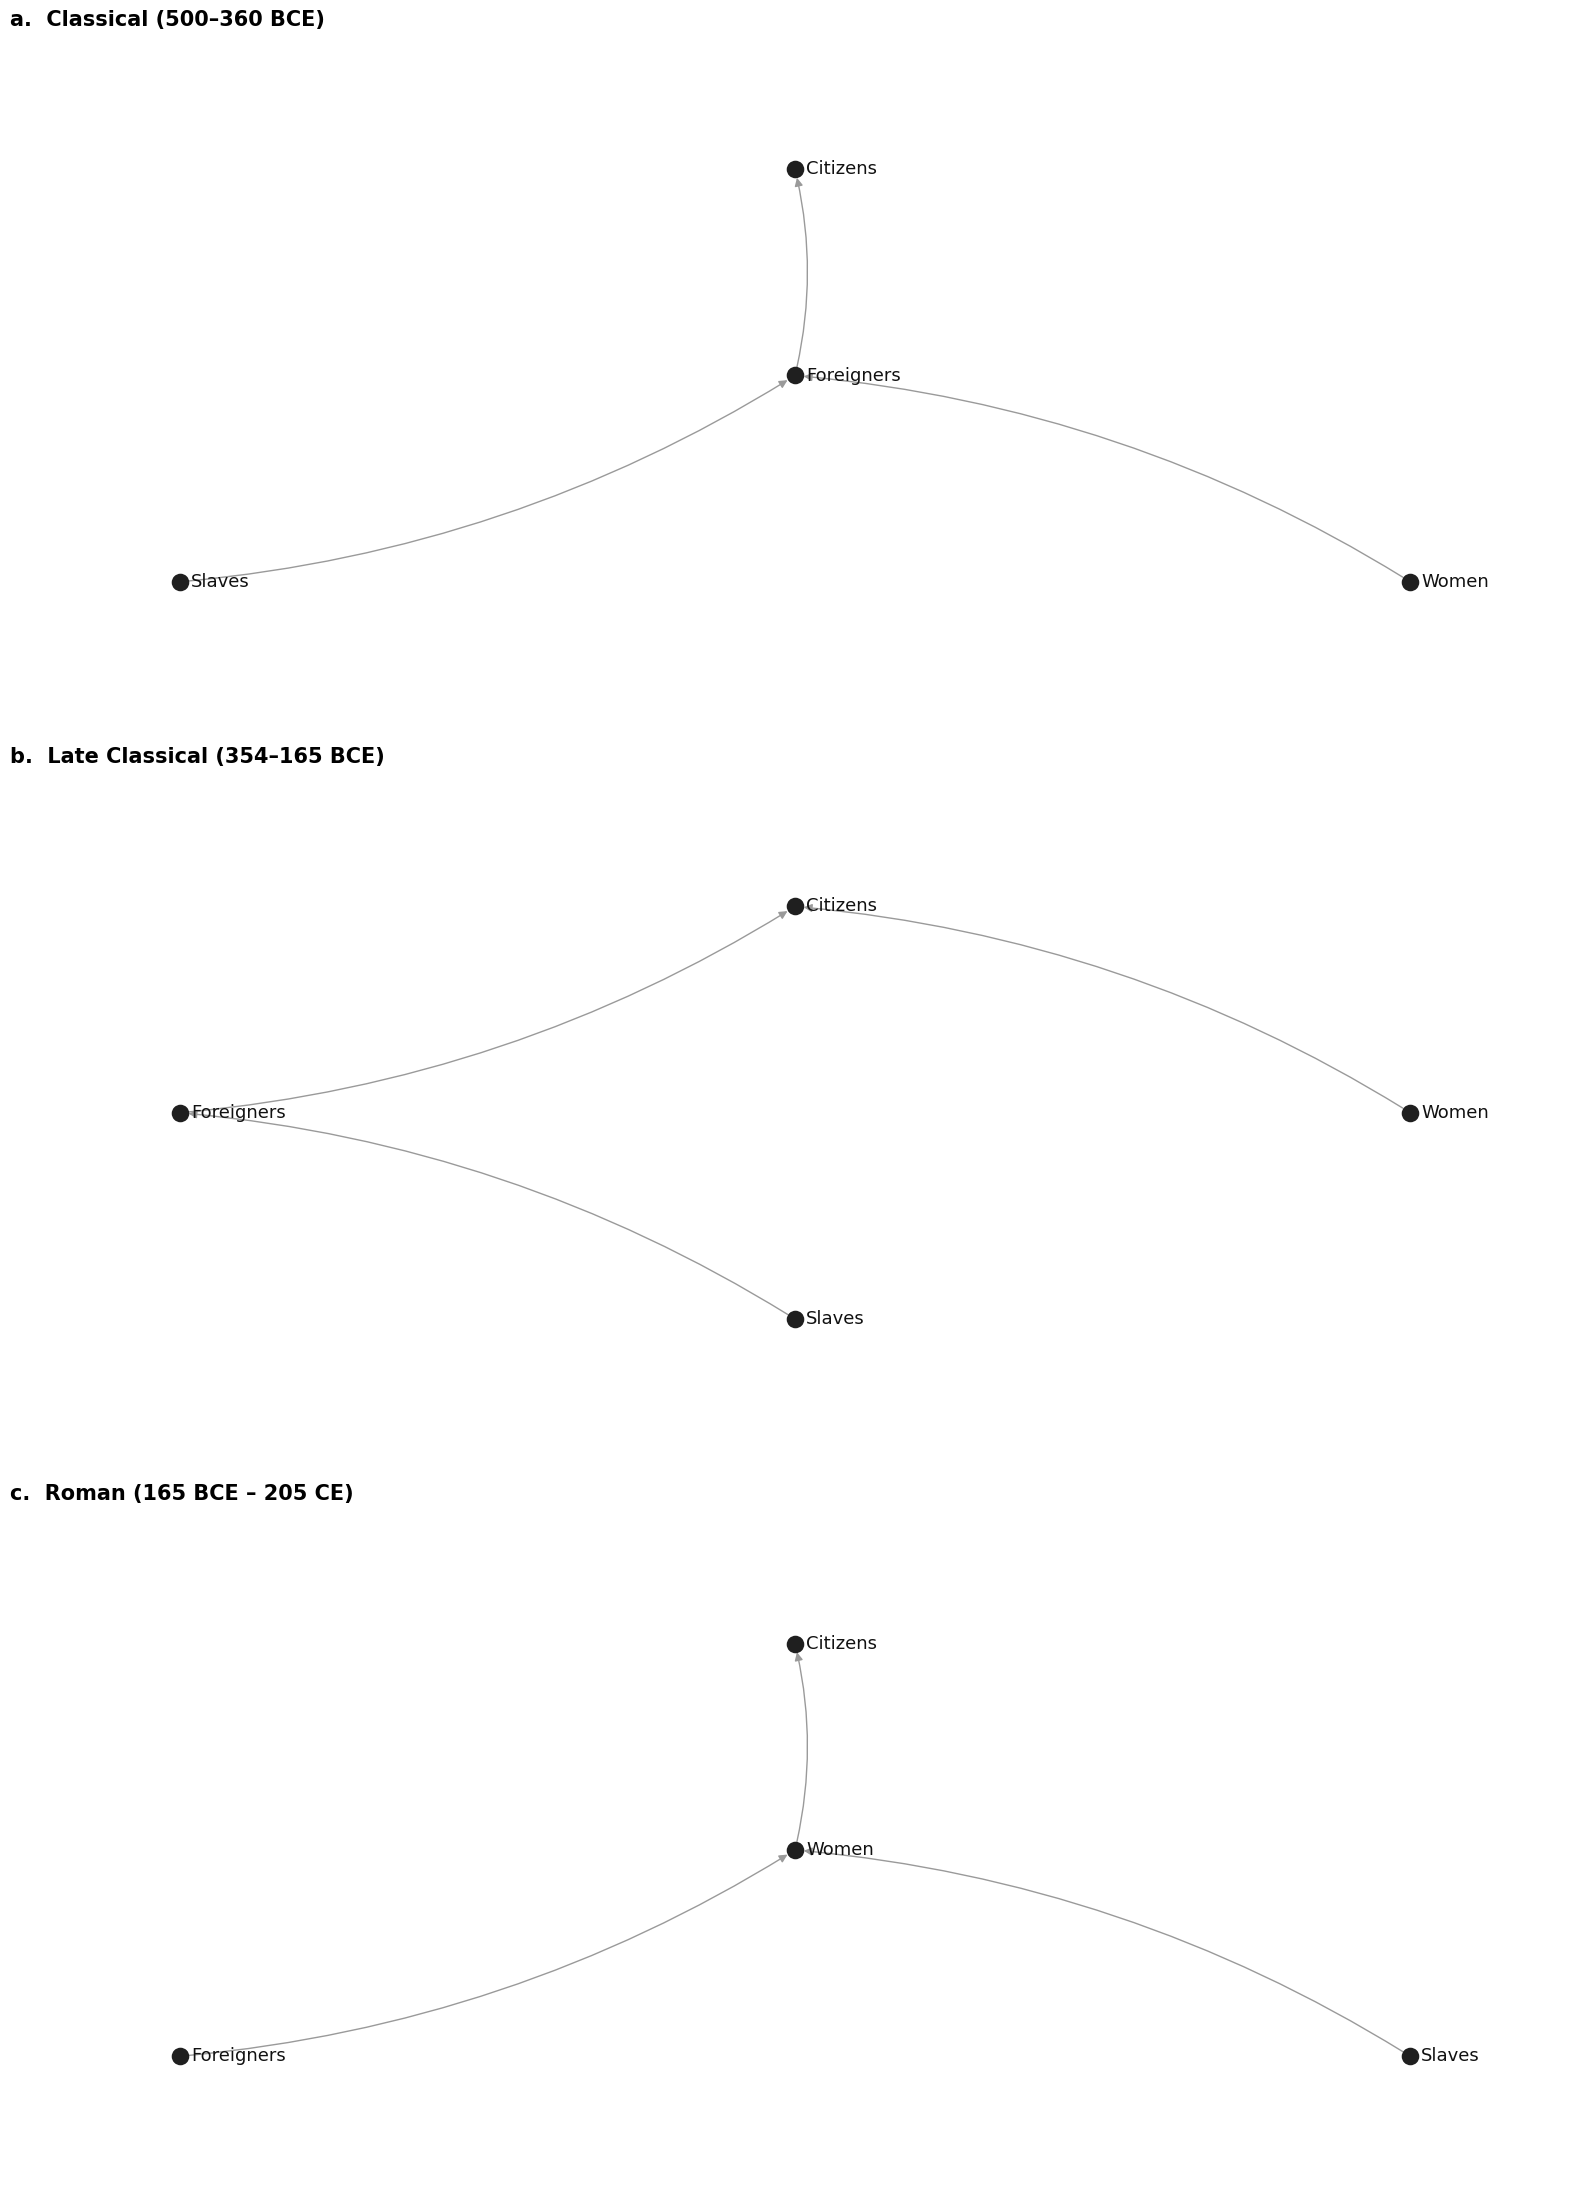

In [11]:
plt.rcParams.update({
    'font.family':     'DejaVu Sans',
    'axes.labelsize':  14,
    'axes.titlesize':  15,
    'xtick.labelsize': 11,
    'ytick.labelsize': 12,
})
NODE_SIZE = 160
fig, axes = plt.subplots(3, 1, figsize=(16, 22))

for letter, ax, period in zip('abc', axes, PERIOD_ORDER):
    sets = right_sets(period)
    G, classes = approx_graph(sets)
    pos = topological_positions(G)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=NODE_SIZE, node_color='#1f1f1f', linewidths=0)
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color='#9a9a9a', width=1.0,
                            arrows=True, arrowstyle='-|>', arrowsize=12,
                            node_size=NODE_SIZE, connectionstyle='arc3,rad=0.12',
                            min_source_margin=4, min_target_margin=4)
    for n, (x, y) in pos.items():
        ax.annotate(', '.join(classes[n]), xy=(x, y), xytext=(8, 0),
                    textcoords='offset points', ha='left', va='center',
                    fontsize=13, color='#111111')
    ymax = max(y for _, y in pos.values()) if pos else 0
    ax.set_title(f'{letter}.  {period}', fontsize=15, loc='left', pad=14, weight='semibold')
    ax.set_xticks([]); ax.set_yticks([]); ax.tick_params(axis='both', length=0)
    ax.set_ylim(-0.6, ymax + 0.6); ax.margins(x=0.08)
    for s in ('top', 'right', 'bottom', 'left'):
        ax.spines[s].set_visible(False)

fig.tight_layout(h_pad=3)
plt.show()

In [12]:
for period in PERIOD_ORDER:
    sets = right_sets(period)
    print(f'=== {period} ===')
    for g in CANONICAL_GROUPS:
        if g in sets:
            rights = sorted(sets[g])
            print(f'{g} ({len(rights)}) = {{ {", ".join(rights)} }}')
        else:
            print(f'{g} (—) = {{ }}    # below MIN_RIGHTS={MIN_RIGHTS}')
    print()

=== Classical (500–360 BCE) ===
Citizens (8) = { Eligibility for public office, Political power, Protection from capital / corporal punishment, Right to a legal trial, Right to dispose / inherit property, Right to public speech, Right to retain property, Right to vote in the Ekklesia }
Women (4) = { Right to dispose / inherit property, Right to marriage / dowry, Right to public speech, Right to retain property }
Slaves (4) = { Protection from capital / corporal punishment, Right to a legal trial, Right to public speech, Right to retain property }
Foreigners (6) = { Eligibility for public office, Political power, Protection from capital / corporal punishment, Right to a legal trial, Right to dispose / inherit property, Right to public speech }

=== Late Classical (354–165 BCE) ===
Citizens (9) = { Eligibility for public office, Political power, Protection from capital / corporal punishment, Right to a legal trial, Right to dispose / inherit property, Right to marriage / dowry, Right to 

## Rights by origin — positive (MORE) vs inferred (flipped LESS)

Three panels (one per period), restricted to the curated `COMPARABLE_RIGHTS`. Cell colours:

* **Blue** — at least one positive `MORE` rule
* **Orange** — only inferred via the asymmetric `LESS → MORE` flip
* **Purple** — both positive *and* inferred evidence
* **Empty** — no evidence in this period

The numbers in each cell are `M / F` — count of MORE rules and count of flipped-LESS rules feeding that (group, right, period) cell.

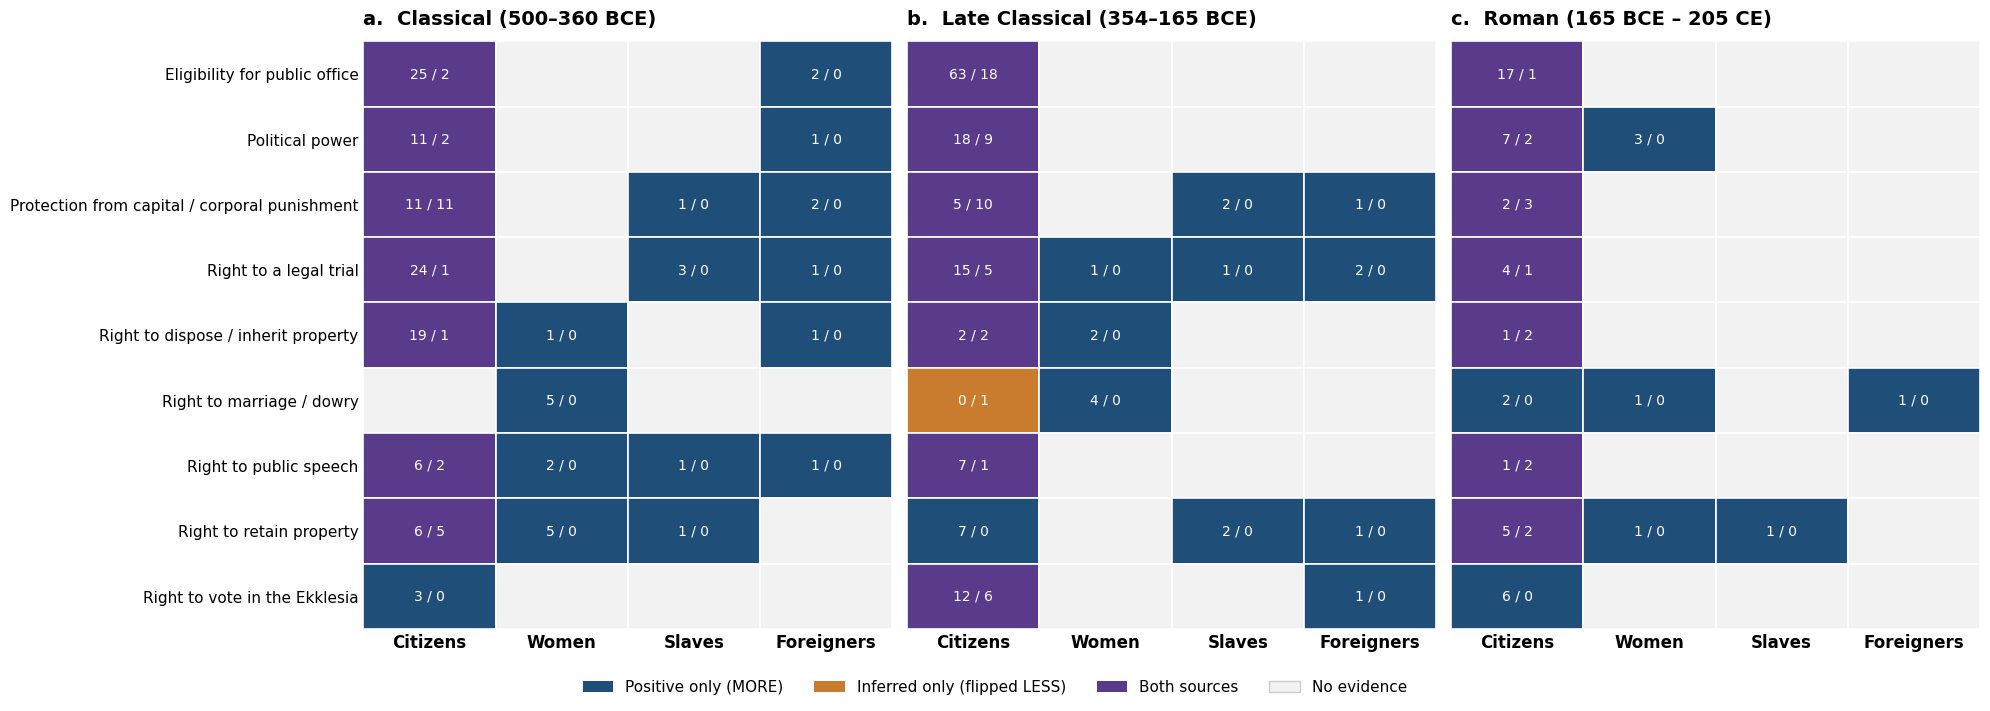

In [13]:
origin_counts = (positive[positive['resource_bucket'].isin(COMPARABLE_RIGHTS)]
                 .groupby(['period', 'group', 'resource_bucket', 'origin'])
                 .size()
                 .unstack('origin', fill_value=0)
                 .reset_index())
for col in ('MORE', 'flipped LESS'):
    if col not in origin_counts.columns:
        origin_counts[col] = 0

plt.rcParams.update({
    'font.family':     'DejaVu Sans',
    'axes.labelsize':  12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 11,
})

groups_x = CANONICAL_GROUPS
rights_y = sorted(COMPARABLE_RIGHTS)

def cell_color(m, f):
    if m > 0 and f > 0: return COLOR_BOTH
    if m > 0:           return COLOR_MORE
    if f > 0:           return COLOR_FLIP
    return COLOR_EMPTY

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for letter, ax, period in zip('abc', axes, PERIOD_ORDER):
    sub = origin_counts[origin_counts['period'] == period]
    n_rows, n_cols = len(rights_y), len(groups_x)
    M = np.zeros((n_rows, n_cols), dtype=int)
    F = np.zeros((n_rows, n_cols), dtype=int)
    for _, r in sub.iterrows():
        if r['group'] not in groups_x or r['resource_bucket'] not in rights_y:
            continue
        i = rights_y.index(r['resource_bucket'])
        j = groups_x.index(r['group'])
        M[i, j] = int(r.get('MORE', 0))
        F[i, j] = int(r.get('flipped LESS', 0))

    for i in range(n_rows):
        for j in range(n_cols):
            color = cell_color(M[i, j], F[i, j])
            ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1,
                                       facecolor=color, edgecolor='white', linewidth=1.2))
            if M[i, j] or F[i, j]:
                txt_color = '#ffffff' if color != COLOR_EMPTY else '#111111'
                ax.text(j, i, f'{M[i,j]} / {F[i,j]}',
                        ha='center', va='center', fontsize=10, color=txt_color)

    ax.set_xlim(-0.5, n_cols - 0.5)
    ax.set_ylim(n_rows - 0.5, -0.5)
    ax.set_xticks(range(n_cols))
    ax.set_xticklabels(groups_x, rotation=0, fontsize=12, weight='semibold')
    ax.set_yticks(range(n_rows))
    if letter == 'a':
        ax.set_yticklabels(rights_y, fontsize=11)
    else:
        ax.set_yticklabels([''] * n_rows)
    ax.tick_params(axis='both', length=0)
    ax.set_title(f'{letter}.  {period}', fontsize=14, loc='left', pad=12, weight='semibold')
    for s in ('top', 'right', 'bottom', 'left'):
        ax.spines[s].set_visible(False)

legend_handles = [
    Patch(facecolor=COLOR_MORE,  label='Positive only (MORE)'),
    Patch(facecolor=COLOR_FLIP,  label='Inferred only (flipped LESS)'),
    Patch(facecolor=COLOR_BOTH,  label='Both sources'),
    Patch(facecolor=COLOR_EMPTY, edgecolor='#cccccc', label='No evidence'),
]
fig.legend(handles=legend_handles, loc='lower center', ncol=4, frameon=False,
           fontsize=11, bbox_to_anchor=(0.5, -0.02))
fig.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()